# PROMPT LANJUTAN UTS AI A — Sensor LC vs PS Cyclic Voltammetry
## Part 4 — Feature Engineering Lanjutan + Advanced Modeling
### Phase 1 & 2: Load Dataset, Preprocessing, & Feature Engineering (16 Fitur)

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy import stats
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

BASE_DIR = Path('.')
LC_DIR   = BASE_DIR / 'Alat Sensor LC'
PS_DIR   = BASE_DIR / 'Alat Sensor PS'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

PPM_LEVELS   = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000]
STABLE_SCANS = list(range(2, 10))   # scan indeks 2-9 (8 scan stabil per file)

# Window per-sensor untuk Anodic (Upper) Peak
UPPER_V_MIN_LC, UPPER_V_MAX_LC = -0.62, -0.43
UPPER_V_MIN_PS, UPPER_V_MAX_PS = -0.80, -0.43

# Window per-sensor untuk Cathodic (Lower) Peak
LOWER_V_MIN_LC, LOWER_V_MAX_LC = -0.80, -0.40
LOWER_V_MIN_PS, LOWER_V_MAX_PS = -0.90, -0.45


In [2]:
def load_cv_file(filepath, sensor_type='LC'):
    try:
        if sensor_type == 'LC':
            df = pd.read_excel(filepath, header=[0,1], sheet_name='Data CV')
        else:
            df = pd.read_excel(filepath, header=[0,1], sheet_name=0)
    except Exception:
        df = pd.read_excel(filepath, header=[0,1], sheet_name=0)
        
    if isinstance(df, dict):
        df = list(df.values())[0]
        
    scans = {}
    n_scans = df.shape[1] // 2
    for s in range(n_scans):
        v = df.iloc[:, s*2].dropna().values.astype(float)
        i = df.iloc[:, s*2+1].dropna().values.astype(float)
        if len(v) > 10:
            scans[s] = {'V': v, 'I': i}
    return scans

def get_anodic_sweep(v, i, starts_anodic=True):
    if len(v) < 5: return v, i
    if starts_anodic:
        # LC: starts anodic -> anodic sweep = awal sampai turn point (max)
        turn_idx = np.argmax(v)
        return v[:turn_idx+1], i[:turn_idx+1]
    else:
        # PS: starts cathodic -> anodic sweep = turn point (min) sampai akhir
        turn_idx = np.argmin(v)
        return v[turn_idx:], i[turn_idx:]

def get_cathodic_sweep(v, i, starts_anodic=True):
    if len(v) < 5: return v, i
    if starts_anodic:
        # LC: starts anodic -> cathodic sweep = setelah turn point (max)
        turn_idx = np.argmax(v)
        return v[turn_idx:], i[turn_idx:]
    else:
        # PS: starts cathodic -> cathodic sweep = sebelum turn point (min)
        turn_idx = np.argmin(v)
        return v[:turn_idx+1], i[:turn_idx+1]


In [3]:
def calc_fwhm(vw, iw):
    if len(iw) < 3: return float('nan')
    peak_idx = np.argmax(iw)
    half_max = iw[peak_idx] / 2.0
    left = np.where(iw[:peak_idx] <= half_max)[0]
    right = np.where(iw[peak_idx:] <= half_max)[0]
    if len(left) == 0 or len(right) == 0:
        return float('nan')
    v_left = vw[left[-1]]
    v_right = vw[peak_idx + right[0]]
    return abs(v_right - v_left)

def calc_fwhm_cathodic(vw, iw_corrected):
    # For cathodic, iw_corrected is already flipped to be positive
    return calc_fwhm(vw, iw_corrected)

def extract_upper_peak(v, i, v_min, v_max):
    mask = (v >= v_min) & (v <= v_max)
    vw, iw = v[mask], i[mask]
    if len(vw) < 10:
        return {k: np.nan for k in ['upper_Ip_mean','upper_Ip_std','upper_Ep_mean','upper_Ep_std','upper_Area_mean','upper_FWHM_mean','upper_skewness','upper_kurtosis']}
    
    iw = savgol_filter(iw, window_length=9, polyorder=3)
    baseline = np.percentile(iw, 5)
    iw_corr = iw - baseline
    
    peak_idx = np.argmax(iw_corr)
    Ip = iw_corr[peak_idx]
    Ep = vw[peak_idx]
    Area = np.trapz(iw_corr, x=vw) if hasattr(np, 'trapz') else np.trapezoid(iw_corr, x=vw)
    FWHM = calc_fwhm(vw, iw_corr)
    skewness = float(stats.skew(iw))
    kurtosis = float(stats.kurtosis(iw))
    
    return {
        'Ip': Ip, 'Ep': Ep, 'Area': Area, 'FWHM': FWHM, 
        'skewness': skewness, 'kurtosis': kurtosis
    }

def extract_lower_peak(v, i, v_min, v_max):
    mask = (v >= v_min) & (v <= v_max)
    vw, iw = v[mask], i[mask]
    if len(vw) < 10:
        return {k: np.nan for k in ['lower_Ip_mean','lower_Ip_std','lower_Ep_mean','lower_Ep_std','lower_Area_mean','lower_FWHM_mean','lower_skewness','lower_kurtosis']}
    
    iw = savgol_filter(iw, window_length=9, polyorder=3)
    baseline = np.percentile(iw, 95)
    iw_corr = baseline - iw # flip agar positif
    
    # Karena kita sudah flip, peak_idx adalah argmax(iw_corr)
    peak_idx = np.argmax(iw_corr)
    Ip = iw_corr[peak_idx] # ini abs(current)
    Ep = vw[peak_idx]
    
    # Urutkan berdasarkan V untuk trapz agar Area positif jika V tidak urut menaik
    sort_idx = np.argsort(vw)
    Area = np.trapz(iw_corr[sort_idx], x=vw[sort_idx]) if hasattr(np, 'trapz') else np.trapezoid(iw_corr[sort_idx], x=vw[sort_idx])
    Area = abs(Area)
    
    FWHM = calc_fwhm_cathodic(vw, iw_corr)
    skewness = float(stats.skew(iw))
    kurtosis = float(stats.kurtosis(iw))
    
    return {
        'Ip': Ip, 'Ep': Ep, 'Area': Area, 'FWHM': FWHM, 
        'skewness': skewness, 'kurtosis': kurtosis
    }


In [4]:
def process_single_file_v2(filepath, sensor_type, ppm_level):
    scans = load_cv_file(filepath, sensor_type)
    if not scans:
        return None
        
    starts_anodic = True if sensor_type == 'LC' else False
    
    u_v_min, u_v_max = (UPPER_V_MIN_LC, UPPER_V_MAX_LC) if sensor_type == 'LC' else (UPPER_V_MIN_PS, UPPER_V_MAX_PS)
    l_v_min, l_v_max = (LOWER_V_MIN_LC, LOWER_V_MAX_LC) if sensor_type == 'LC' else (LOWER_V_MIN_PS, LOWER_V_MAX_PS)
    
    u_Ips, u_Eps, u_Areas, u_FWHMs, u_skews, u_kurts = [], [], [], [], [], []
    l_Ips, l_Eps, l_Areas, l_FWHMs, l_skews, l_kurts = [], [], [], [], [], []
    
    for s in STABLE_SCANS:
        if s not in scans: continue
        v_raw, i_raw = scans[s]['V'], scans[s]['I']
        
        v_ano, i_ano = get_anodic_sweep(v_raw, i_raw, starts_anodic)
        v_cat, i_cat = get_cathodic_sweep(v_raw, i_raw, starts_anodic)
        
        u_feat = extract_upper_peak(v_ano, i_ano, u_v_min, u_v_max)
        l_feat = extract_lower_peak(v_cat, i_cat, l_v_min, l_v_max)
        
        if not np.isnan(u_feat.get('Ip', np.nan)):
            u_Ips.append(u_feat['Ip'])
            u_Eps.append(u_feat['Ep'])
            u_Areas.append(u_feat['Area'])
            u_FWHMs.append(u_feat['FWHM'])
            u_skews.append(u_feat['skewness'])
            u_kurts.append(u_feat['kurtosis'])
            
        if not np.isnan(l_feat.get('Ip', np.nan)):
            l_Ips.append(l_feat['Ip'])
            l_Eps.append(l_feat['Ep'])
            l_Areas.append(l_feat['Area'])
            l_FWHMs.append(l_feat['FWHM'])
            l_skews.append(l_feat['skewness'])
            l_kurts.append(l_feat['kurtosis'])
            
    if len(u_Ips) == 0:
        return None
        
    return {
        'ppm': ppm_level,
        'upper_Ip_mean': np.nanmean(u_Ips) if len(u_Ips) > 0 else np.nan,
        'upper_Ip_std': np.nanstd(u_Ips) if len(u_Ips) > 0 else np.nan,
        'upper_Ep_mean': np.nanmean(u_Eps) if len(u_Eps) > 0 else np.nan,
        'upper_Ep_std': np.nanstd(u_Eps) if len(u_Eps) > 0 else np.nan,
        'upper_Area_mean': np.nanmean(u_Areas) if len(u_Areas) > 0 else np.nan,
        'upper_FWHM_mean': np.nanmean(u_FWHMs) if len(u_FWHMs) > 0 else np.nan,
        'upper_skewness': np.nanmean(u_skews) if len(u_skews) > 0 else np.nan,
        'upper_kurtosis': np.nanmean(u_kurts) if len(u_kurts) > 0 else np.nan,
        
        'lower_Ip_mean': np.nanmean(l_Ips) if len(l_Ips) > 0 else np.nan,
        'lower_Ip_std': np.nanstd(l_Ips) if len(l_Ips) > 0 else np.nan,
        'lower_Ep_mean': np.nanmean(l_Eps) if len(l_Eps) > 0 else np.nan,
        'lower_Ep_std': np.nanstd(l_Eps) if len(l_Eps) > 0 else np.nan,
        'lower_Area_mean': np.nanmean(l_Areas) if len(l_Areas) > 0 else np.nan,
        'lower_FWHM_mean': np.nanmean(l_FWHMs) if len(l_FWHMs) > 0 else np.nan,
        'lower_skewness': np.nanmean(l_skews) if len(l_skews) > 0 else np.nan,
        'lower_kurtosis': np.nanmean(l_kurts) if len(l_kurts) > 0 else np.nan,
    }

def build_dataset_v2(sensor_dir, sensor_type):
    data = []
    
    # KCL (0 ppm)
    kcl_dir = sensor_dir / 'KCL'
    if kcl_dir.exists():
        for f in kcl_dir.glob('*.xlsx'):
            res = process_single_file_v2(f, sensor_type, 0)
            if res: data.append(res)
            
    # Other PPM levels
    for ppm in PPM_LEVELS:
        ppm_dir = sensor_dir / f'{ppm} ppm'
        if not ppm_dir.exists(): ppm_dir = sensor_dir / f'{ppm} PPM'
        if not ppm_dir.exists(): ppm_dir = sensor_dir / f'{ppm}ppm'
        if not ppm_dir.exists(): ppm_dir = sensor_dir / str(ppm)
            
        if ppm_dir.exists():
            for f in ppm_dir.glob('*.xlsx'):
                res = process_single_file_v2(f, sensor_type, ppm)
                if res: data.append(res)
        else:
            print(f"Warning: Directory not found for {ppm} ppm in {sensor_dir}")
    
    return pd.DataFrame(data)


In [5]:
print("Memproses dataset LC...")
df_lc = build_dataset_v2(LC_DIR, 'LC')
print(f"Dataset LC selesai: {len(df_lc)} sampel")

print("Memproses dataset PS...")
df_ps = build_dataset_v2(PS_DIR, 'PS')
print(f"Dataset PS selesai: {len(df_ps)} sampel")


Memproses dataset LC...


Dataset LC selesai: 800 sampel
Memproses dataset PS...


Dataset PS selesai: 797 sampel


In [6]:
# Simpan ke CSV (Raw)
df_lc.to_csv(OUTPUT_DIR / 'dataset_lc_v4_raw.csv', index=False)
df_ps.to_csv(OUTPUT_DIR / 'dataset_ps_v4_raw.csv', index=False)

# Phase 2: Impute features with median PER PPM LEVEL
def impute_missing_per_ppm(df):
    feature_cols = [c for c in df.columns if c.startswith('upper_') or c.startswith('lower_')]
    df_imp = df.copy()
    for col in feature_cols:
        # 1. Impute dengan median dari masing-masing level ppm
        df_imp[col] = df_imp.groupby('ppm')[col].transform(lambda x: x.fillna(x.median()) if not x.isna().all() else x)
        
        # 2. Fallback: jika di suatu level ppm nilainya NaN semua, gunakan global median
        if df_imp[col].isna().any():
            df_imp[col] = df_imp[col].fillna(df_imp[col].median())
            
        # 3. Fallback terakhir: jika seluruh kolom NaN, isi dengan 0
        if df_imp[col].isna().all():
            df_imp[col] = df_imp[col].fillna(0.0)
    return df_imp

print("Melakukan imputasi missing values (NaN) menggunakan median per ppm level...")
df_lc_imputed = impute_missing_per_ppm(df_lc)
df_ps_imputed = impute_missing_per_ppm(df_ps)

# Simpan ke CSV (Imputed)
df_lc_imputed.to_csv(OUTPUT_DIR / 'dataset_lc_v4_imputed.csv', index=False)
df_ps_imputed.to_csv(OUTPUT_DIR / 'dataset_ps_v4_imputed.csv', index=False)

# Tampilkan Statistik LC
print("=== Statistik LC (Raw) ===")
print("Shape:", df_lc.shape)
print("Missing values:\n", df_lc.isna().sum()[df_lc.isna().sum() > 0])

# Tampilkan Statistik PS
print("\n=== Statistik PS (Raw) ===")
print("Shape:", df_ps.shape)
print("Missing values:\n", df_ps.isna().sum()[df_ps.isna().sum() > 0])

print("\nMissing values setelah imputasi LC:", df_lc_imputed.isna().sum().sum())
print("Missing values setelah imputasi PS:", df_ps_imputed.isna().sum().sum())

# Verifikasi
assert df_lc.shape[0] == 800, f"Expected 800 samples for LC, got {df_lc.shape[0]}"
assert 790 <= df_ps.shape[0] <= 800, f"Expected ~797 samples for PS, got {df_ps.shape[0]}"
print("\nVERIFIKASI BERHASIL: Phase 1 & 2 terpenuhi.")

Melakukan imputasi missing values (NaN) menggunakan median per ppm level...


=== Statistik LC (Raw) ===
Shape: (800, 17)
Missing values:
 upper_FWHM_mean    436
lower_FWHM_mean    800
dtype: int64

=== Statistik PS (Raw) ===
Shape: (797, 17)
Missing values:
 upper_FWHM_mean    586
lower_FWHM_mean    797
dtype: int64

Missing values setelah imputasi LC: 0
Missing values setelah imputasi PS: 0

VERIFIKASI BERHASIL: Phase 1 & 2 terpenuhi.


## Phase 3 — EDA (Exploratory Data Analysis)
Visualisasi distribusi fitur, heatmap korelasi dengan target konsentrasi (`ppm`), dan kurva kalibrasi.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statistik deskriptif singkat
print("=== Deskripsi Fitur LC (Setelah Imputasi) ===")
display(df_lc_imputed.describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n=== Deskripsi Fitur PS (Setelah Imputasi) ===")
display(df_ps_imputed.describe().T[['mean', 'std', 'min', '50%', 'max']])

=== Deskripsi Fitur LC (Setelah Imputasi) ===


,mean,std,min,50%,max
ppm,208.125000,309.341801,0.000000,50.000000,1000.000000
upper_Ip_mean,8.430539,19.538610,0.709749,2.834180,88.769639
upper_Ip_std,0.750218,0.904011,0.086310,0.450511,7.184330
upper_Ep_mean,-0.541523,0.041233,-0.620000,-0.518750,-0.500000
upper_Ep_std,0.014049,0.016032,0.000000,0.006960,0.058830
upper_Area_mean,0.500604,1.220068,0.042642,0.155283,5.612287
upper_FWHM_mean,0.057539,0.008969,0.040000,0.055000,0.100000
upper_skewness,0.043566,0.525391,-1.426912,0.058839,1.751070
upper_kurtosis,-0.678789,0.906082,-1.505126,-1.166908,2.615111
lower_Ip_mean,43.997366,43.688143,17.973174,28.516098,217.792284



=== Deskripsi Fitur PS (Setelah Imputasi) ===


,mean,std,min,50%,max
ppm,208.632371,309.812736,0.000000,40.000000,1000.000000
upper_Ip_mean,13.557990,9.752524,4.150540,11.993419,94.960037
upper_Ip_std,0.676910,1.775550,0.016749,0.261878,27.381340
upper_Ep_mean,-0.612767,0.080238,-0.770198,-0.640097,-0.508745
upper_Ep_std,0.008037,0.016908,0.000000,0.003310,0.105171
upper_Area_mean,2.334686,1.302799,0.579185,2.035140,10.233456
upper_FWHM_mean,0.162820,0.019558,0.080062,0.158873,0.230179
upper_skewness,-1.385005,0.685230,-2.978713,-1.512334,0.879842
upper_kurtosis,2.080580,1.988813,-1.457411,1.778225,8.892112
lower_Ip_mean,45.918064,19.450620,27.092913,40.202563,192.723356


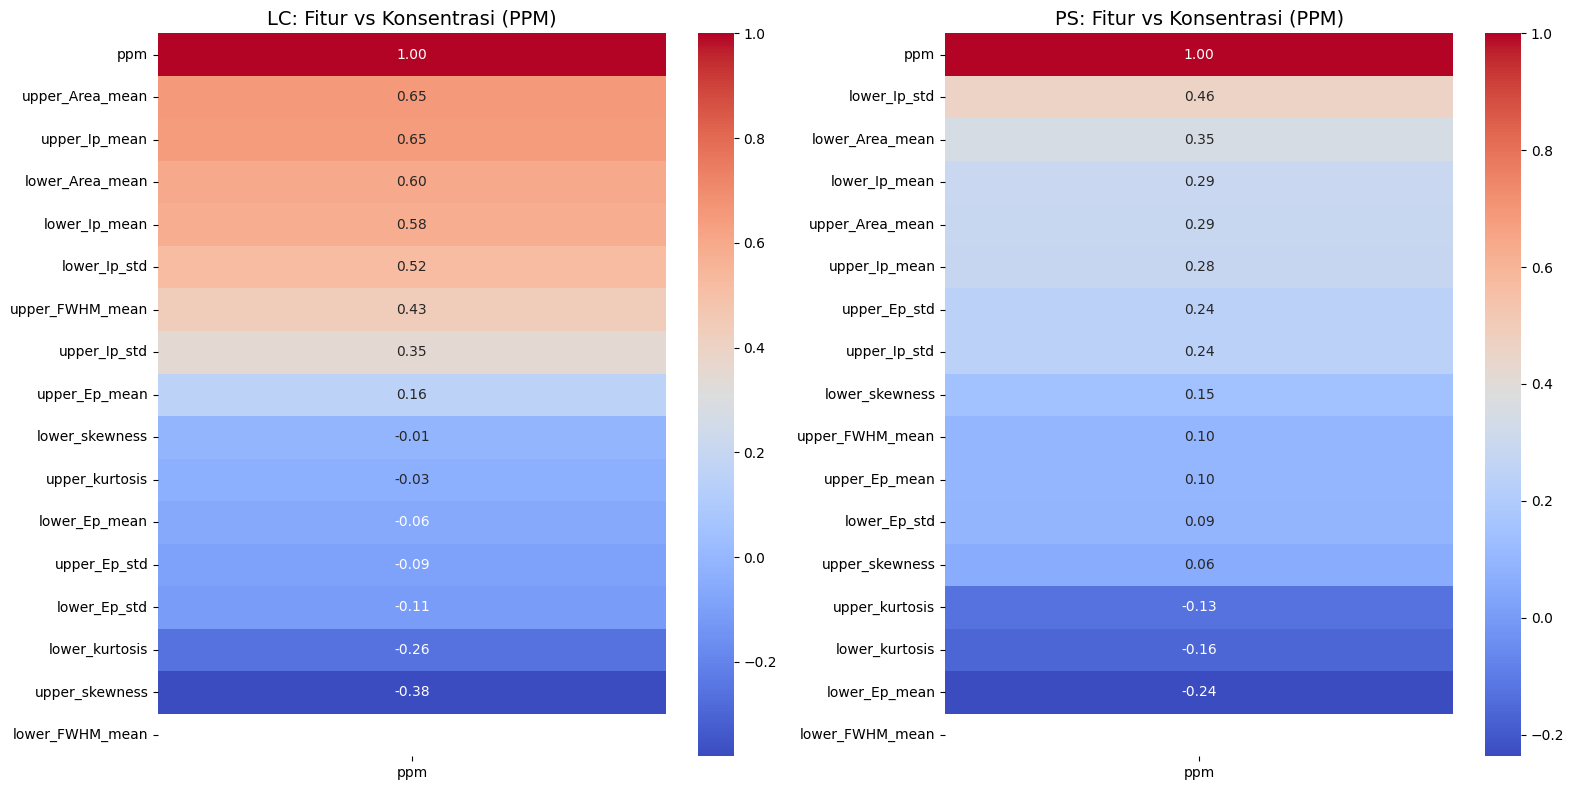

In [8]:
# Hitung korelasi dengan target (ppm)
corr_lc = df_lc_imputed.corr()[['ppm']].sort_values(by='ppm', ascending=False)
corr_ps = df_ps_imputed.corr()[['ppm']].sort_values(by='ppm', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(corr_lc, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('LC: Fitur vs Konsentrasi (PPM)', fontsize=14)

sns.heatmap(corr_ps, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('PS: Fitur vs Konsentrasi (PPM)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase3_korelasi.png', dpi=300)
plt.show()

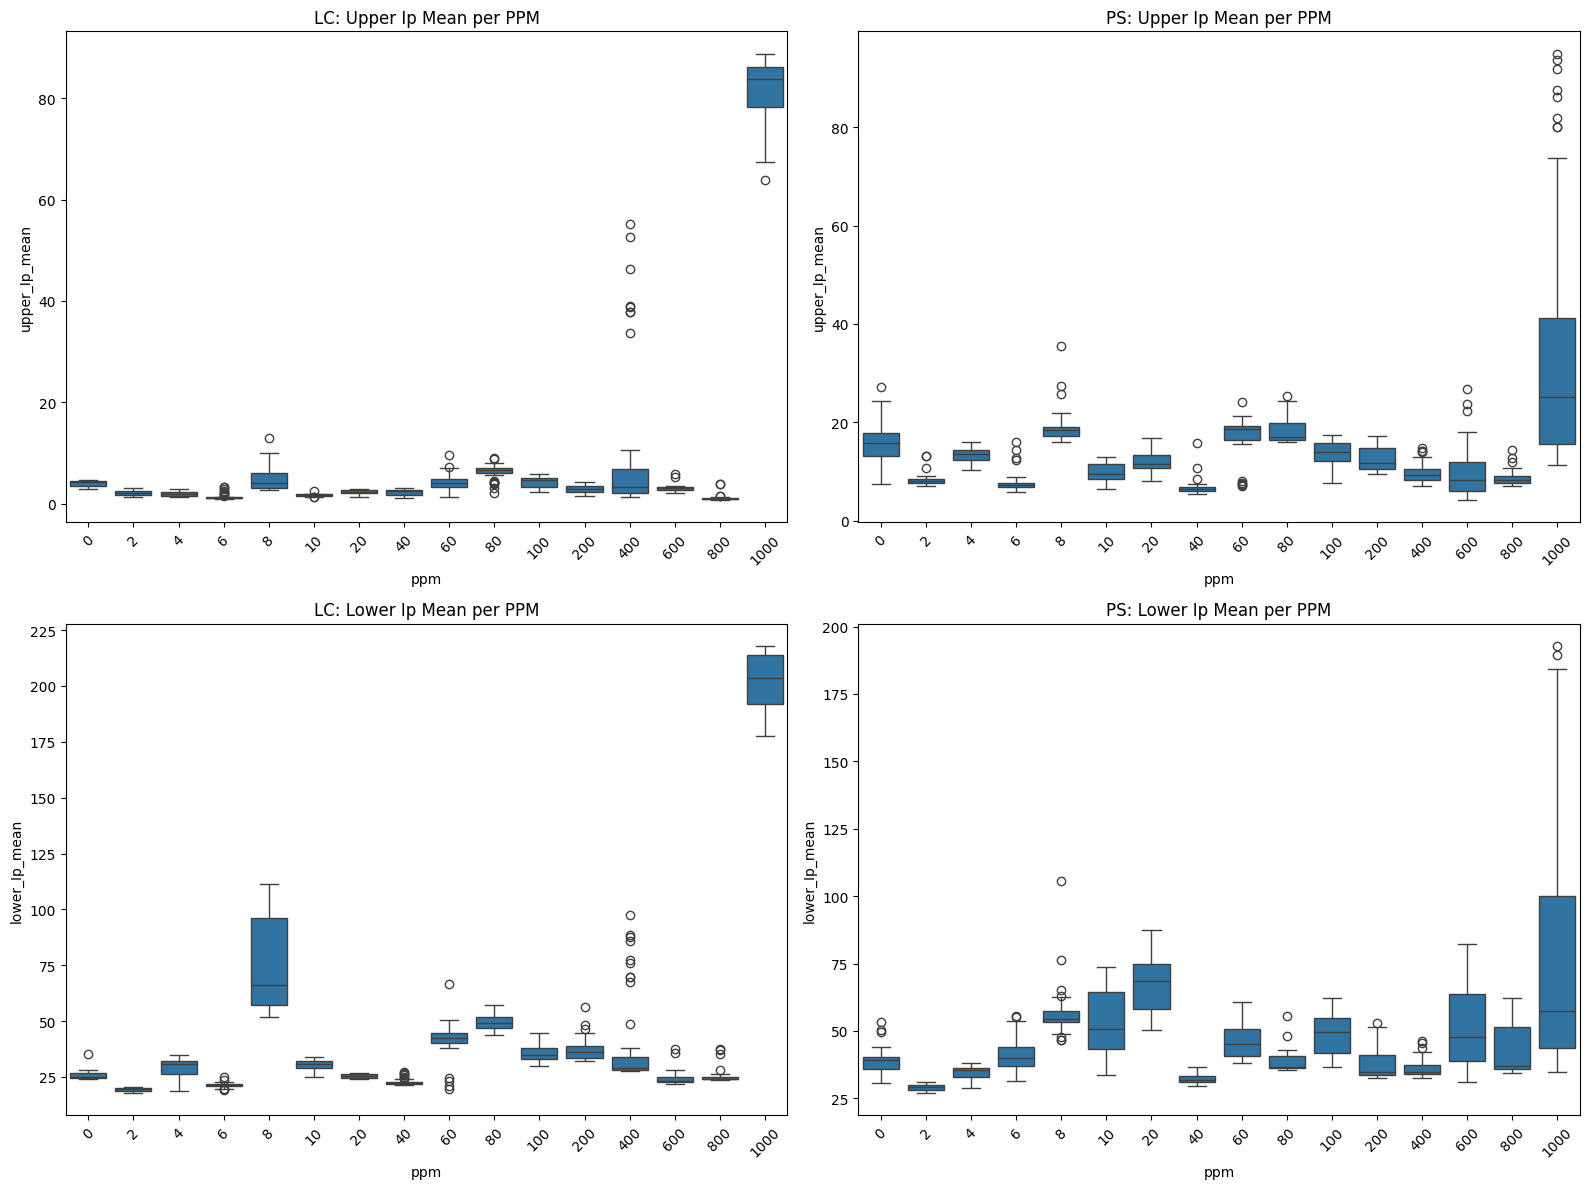

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pilih 2 fitur penting dari upper dan 2 fitur penting dari lower (contoh: Ip_mean dan Area_mean)
sns.boxplot(data=df_lc_imputed, x='ppm', y='upper_Ip_mean', ax=axes[0, 0])
axes[0, 0].set_title('LC: Upper Ip Mean per PPM')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_ps_imputed, x='ppm', y='upper_Ip_mean', ax=axes[0, 1])
axes[0, 1].set_title('PS: Upper Ip Mean per PPM')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_lc_imputed, x='ppm', y='lower_Ip_mean', ax=axes[1, 0])
axes[1, 0].set_title('LC: Lower Ip Mean per PPM')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_ps_imputed, x='ppm', y='lower_Ip_mean', ax=axes[1, 1])
axes[1, 1].set_title('PS: Lower Ip Mean per PPM')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase3_boxplot_ppm.png', dpi=300)
plt.show()

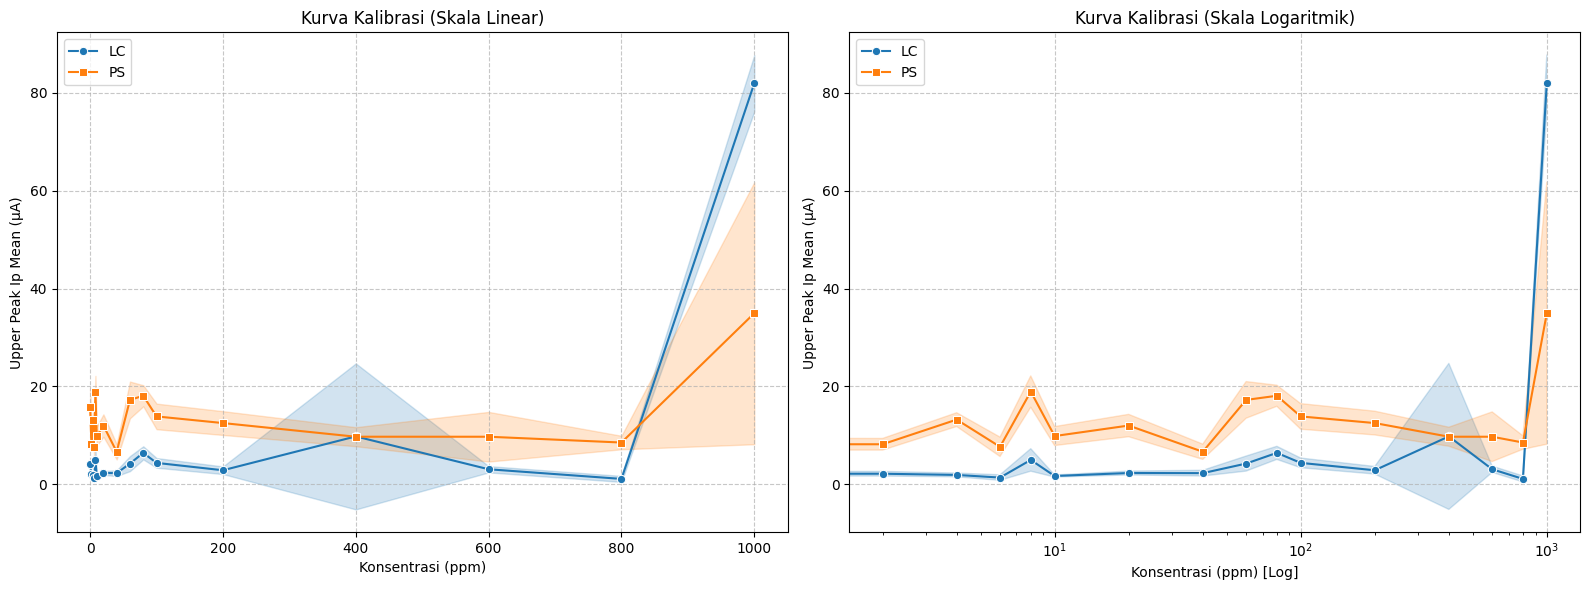

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Scale
sns.lineplot(data=df_lc_imputed, x='ppm', y='upper_Ip_mean', marker='o', label='LC', errorbar='sd', ax=axes[0])
sns.lineplot(data=df_ps_imputed, x='ppm', y='upper_Ip_mean', marker='s', label='PS', errorbar='sd', ax=axes[0])
axes[0].set_title('Kurva Kalibrasi (Skala Linear)')
axes[0].set_xlabel('Konsentrasi (ppm)')
axes[0].set_ylabel('Upper Peak Ip Mean (µA)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Log Scale
sns.lineplot(data=df_lc_imputed, x='ppm', y='upper_Ip_mean', marker='o', label='LC', errorbar='sd', ax=axes[1])
sns.lineplot(data=df_ps_imputed, x='ppm', y='upper_Ip_mean', marker='s', label='PS', errorbar='sd', ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Kurva Kalibrasi (Skala Logaritmik)')
axes[1].set_xlabel('Konsentrasi (ppm) [Log]')
axes[1].set_ylabel('Upper Peak Ip Mean (µA)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase3_calibration_curve.png', dpi=300)
plt.show()

## Phase 4 — Model Training & Hyperparameter Tuning
Target di-transformasi menjadi logaritmik: `y = log10(ppm + 1)`.
Evaluasi menggunakan Stratified 5-Fold CV berdasarkan kategori ppm.

In [11]:
# Import library ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy

try:
    from tabicl import TabICLRegressor
    HAS_TABICL = True
except ImportError:
    print("Warning: tabicl tidak terinstall. Jalankan: pip install tabicl")
    HAS_TABICL = False

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [12]:
# Pastikan tidak ada NaN. Jika ada, fill dengan 0
feature_cols = [c for c in df_lc_imputed.columns if c.startswith('upper_') or c.startswith('lower_')]

X_lc = df_lc_imputed[feature_cols].fillna(0).values
y_lc = np.log10(df_lc_imputed['ppm'].values + 1)

X_ps = df_ps_imputed[feature_cols].fillna(0).values
y_ps = np.log10(df_ps_imputed['ppm'].values + 1)

# Skala fitur
scaler_lc = StandardScaler()
X_lc_scaled = scaler_lc.fit_transform(X_lc)

scaler_ps = StandardScaler()
X_ps_scaled = scaler_ps.fit_transform(X_ps)

# Stratifikasi berdasarkan kategori ppm
def get_stratify_labels(ppm_array):
    return ppm_array.astype(str)

labels_lc = get_stratify_labels(df_lc_imputed['ppm'].values)
labels_ps = get_stratify_labels(df_ps_imputed['ppm'].values)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary untuk menyimpan hasil
results = {'LC': {}, 'PS': {}}
best_models = {'LC': {}, 'PS': {}}

In [13]:
def evaluate_sklearn_model(name, model, X, y, labels, sensor):
    r2_list, rmse_list, mae_list, mape_list = [], [], [], []
    
    for train_idx, val_idx in skf.split(X, labels):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        m = copy.deepcopy(model)
        m.fit(X_tr, y_tr)
        preds_log = m.predict(X_val)
        
        # Inverse transform
        y_val_inv = (10 ** y_val) - 1
        preds_inv = np.maximum(0, (10 ** preds_log) - 1)
        
        r2_list.append(r2_score(y_val_inv, preds_inv))
        rmse_list.append(np.sqrt(mean_squared_error(y_val_inv, preds_inv)))
        mae_list.append(mean_absolute_error(y_val_inv, preds_inv))
        
        mask = y_val_inv > 0
        if np.sum(mask) > 0:
            mape_list.append(mean_absolute_percentage_error(y_val_inv[mask], preds_inv[mask]))
            
    res = {
        'R2': np.mean(r2_list), 'RMSE': np.mean(rmse_list),
        'MAE': np.mean(mae_list), 'MAPE': np.mean(mape_list) if mape_list else np.nan
    }
    results[sensor][name] = res
    print(f"{sensor} - {name:20s} | R2: {res['R2']:.4f} | RMSE: {res['RMSE']:.2f}")
    best_models[sensor][name] = model # Simpan referensi model (belum di-fit di seluruh data)

In [14]:
# --- 1-4: Baseline Linear ---
linear_models = {
    '1. LinearRegression': LinearRegression(),
    '2. Ridge': Ridge(alpha=1.0),
    '3. ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    '4. PolyRidge': make_pipeline(PolynomialFeatures(degree=2), Ridge(alpha=1.0))
}

# --- 5: Kernel / SVM ---
svm_models = {
    '5. SVR': SVR(kernel='rbf', C=500, gamma='scale')
}

# --- 6-7: Tree Ensemble ---
tree_models = {
    '6. RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    '7. ExtraTrees': ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
}

all_baselines = {**linear_models, **svm_models, **tree_models}

print("Mengevaluasi Model Baseline (1-7)...")
for name, model in all_baselines.items():
    evaluate_sklearn_model(name, model, X_lc_scaled, y_lc, labels_lc, 'LC')
    evaluate_sklearn_model(name, model, X_ps_scaled, y_ps, labels_ps, 'PS')
print("Selesai mengevaluasi baseline.")

Mengevaluasi Model Baseline (1-7)...
LC - 1. LinearRegression  | R2: -9.5326 | RMSE: 761.89
PS - 1. LinearRegression  | R2: -248328359.4382 | RMSE: 2184290.08
LC - 2. Ridge             | R2: -1.1114 | RMSE: 384.59
PS - 2. Ridge             | R2: -254069229.3718 | RMSE: 2209366.35
LC - 3. ElasticNet        | R2: 0.2953 | RMSE: 259.28
PS - 3. ElasticNet        | R2: -7057.1411 | RMSE: 11885.34
LC - 4. PolyRidge         | R2: -866843141976.5277 | RMSE: 128730861.20
PS - 4. PolyRidge         | R2: -1928896507537895330649992975197443859209928339659934937260075101882676786936213805716988224193603567616.0000 | RMSE: 192514386372242261293589728390561856584995973961351168.00
LC - 5. SVR               | R2: 0.6739 | RMSE: 175.00
PS - 5. SVR               | R2: -3.6866 | RMSE: 547.96
LC - 6. RandomForest      | R2: 0.9381 | RMSE: 73.61
PS - 6. RandomForest      | R2: 0.7711 | RMSE: 147.74
LC - 7. ExtraTrees        | R2: 0.9437 | RMSE: 72.24
PS - 7. ExtraTrees        | R2: 0.8071 | RMSE: 134.66
Se

In [15]:
def tune_xgboost(X, y, labels, sensor):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
            'random_state': 42,
            'n_jobs': -1
        }
        
        cv_scores = []
        for train_idx, val_idx in skf.split(X, labels):
            model = xgb.XGBRegressor(**params)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            # Optuna minimize MSE in log-space
            cv_scores.append(mean_squared_error(y[val_idx], preds))
        return np.mean(cv_scores)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
    evaluate_sklearn_model('8. XGBoost_Tuned', best_model, X, y, labels, sensor)
    return best_model

print("Tuning XGBoost...")
xgb_lc = tune_xgboost(X_lc_scaled, y_lc, labels_lc, 'LC')
xgb_ps = tune_xgboost(X_ps_scaled, y_ps, labels_ps, 'PS')

Tuning XGBoost...
LC - 8. XGBoost_Tuned     | R2: 0.9430 | RMSE: 72.35
PS - 8. XGBoost_Tuned     | R2: 0.7945 | RMSE: 138.79


In [16]:
def tune_lightgbm(X, y, labels, sensor):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
            'random_state': 42,
            'verbose': -1,
            'n_jobs': -1
        }
        
        cv_scores = []
        for train_idx, val_idx in skf.split(X, labels):
            model = lgb.LGBMRegressor(**params)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            cv_scores.append(mean_squared_error(y[val_idx], preds))
        return np.mean(cv_scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_model = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1, n_jobs=-1)
    evaluate_sklearn_model('9. LightGBM_Tuned', best_model, X, y, labels, sensor)
    return best_model

print("Tuning LightGBM...")
lgb_lc = tune_lightgbm(X_lc_scaled, y_lc, labels_lc, 'LC')
lgb_ps = tune_lightgbm(X_ps_scaled, y_ps, labels_ps, 'PS')

Tuning LightGBM...
LC - 9. LightGBM_Tuned    | R2: 0.9311 | RMSE: 79.57
PS - 9. LightGBM_Tuned    | R2: 0.8078 | RMSE: 135.32


In [18]:
def tune_catboost(X, y, labels, sensor):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 100, 500),
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 10, log=True),
            'random_seed': 42,
            'verbose': False,
            'thread_count': -1
        }
        
        cv_scores = []
        for train_idx, val_idx in skf.split(X, labels):
            model = cb.CatBoostRegressor(**params)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            cv_scores.append(mean_squared_error(y[val_idx], preds))
        return np.mean(cv_scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_model = cb.CatBoostRegressor(**study.best_params, random_seed=42, verbose=False, thread_count=-1)
    evaluate_sklearn_model('10. CatBoost_Tuned', best_model, X, y, labels, sensor)
    return best_model

print("Tuning CatBoost...")
cb_lc = tune_catboost(X_lc_scaled, y_lc, labels_lc, 'LC')
cb_ps = tune_catboost(X_ps_scaled, y_ps, labels_ps, 'PS')

Tuning CatBoost...
LC - 10. CatBoost_Tuned   | R2: 0.9483 | RMSE: 69.57
PS - 10. CatBoost_Tuned   | R2: 0.8626 | RMSE: 113.32


In [19]:
if HAS_TABICL:
    print("Mengevaluasi TabICLv2 (Zero-shot)...")
    tabicl_model = TabICLRegressor()
    evaluate_sklearn_model('11. TabICLv2', tabicl_model, X_lc_scaled, y_lc, labels_lc, 'LC')
    evaluate_sklearn_model('11. TabICLv2', tabicl_model, X_ps_scaled, y_ps, labels_ps, 'PS')
else:
    print("TabICLv2 di-skip karena belum terinstall.")

Mengevaluasi TabICLv2 (Zero-shot)...
Checkpoint 'tabicl-regressor-v2-20260212.ckpt' not cached.



tabicl-regressor-v2-20260212.ckpt:   0%|          | 0.00/114M [00:00<?, ?B/s]

LC - 11. TabICLv2         | R2: 0.9970 | RMSE: 16.68
PS - 11. TabICLv2         | R2: 0.9919 | RMSE: 26.21


In [21]:
class CAFF(nn.Module):
    def __init__(self, n_features=16, hidden=64, n_heads=4, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.attn = nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)
        )
    
    def forward(self, x):
        enc = self.encoder(x).unsqueeze(1)
        attn_out, _ = self.attn(enc, enc, enc)
        out = self.decoder(attn_out.squeeze(1))
        return out.squeeze(-1)

def train_eval_caff(X_train, y_train, X_val, y_val, params):
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=params.get('batch_size', 32), shuffle=True)
    
    model = CAFF(n_features=X_train.shape[1], 
                 hidden=params.get('hidden', 64), 
                 n_heads=params.get('n_heads', 4), 
                 dropout=params.get('dropout', 0.1))
                 
    optimizer = optim.Adam(model.parameters(), lr=params.get('lr', 0.001))
    criterion = nn.MSELoss()
    
    model.train()
    for epoch in range(params.get('epochs', 200)):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    with torch.no_grad():
        preds_val = model(torch.FloatTensor(X_val)).numpy()
        
    return preds_val

def evaluate_caff(name, X, y, labels, sensor, params):
    r2_list, rmse_list, mae_list, mape_list = [], [], [], []
    for train_idx, val_idx in skf.split(X, labels):
        preds_log = train_eval_caff(X[train_idx], y[train_idx], X[val_idx], y[val_idx], params)
        
        y_val_inv = (10 ** y[val_idx]) - 1
        preds_inv = np.maximum(0, (10 ** preds_log) - 1)
        
        r2_list.append(r2_score(y_val_inv, preds_inv))
        rmse_list.append(np.sqrt(mean_squared_error(y_val_inv, preds_inv)))
        mae_list.append(mean_absolute_error(y_val_inv, preds_inv))
        mask = y_val_inv > 0
        if np.sum(mask) > 0:
            mape_list.append(mean_absolute_percentage_error(y_val_inv[mask], preds_inv[mask]))
            
    res = {
        'R2': np.mean(r2_list), 'RMSE': np.mean(rmse_list),
        'MAE': np.mean(mae_list), 'MAPE': np.mean(mape_list) if mape_list else np.nan
    }
    results[sensor][name] = res
    print(f"{sensor} - {name:20s} | R2: {res['R2']:.4f} | RMSE: {res['RMSE']:.2f}")

print("Mengevaluasi 12. CAFF (Fixed Params)...")
caff_params = {'hidden': 64, 'n_heads': 4, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'epochs': 100}
evaluate_caff('12. CAFF', X_lc_scaled, y_lc, labels_lc, 'LC', caff_params)
evaluate_caff('12. CAFF', X_ps_scaled, y_ps, labels_ps, 'PS', caff_params)

Mengevaluasi 12. CAFF (Fixed Params)...
LC - 12. CAFF             | R2: 0.7953 | RMSE: 135.47
PS - 12. CAFF             | R2: 0.6566 | RMSE: 181.29


In [22]:
def tune_caff(X, y, labels, sensor):
    def objective(trial):
        params = {
            'hidden': trial.suggest_categorical('hidden', [32, 64, 128]),
            'n_heads': trial.suggest_categorical('n_heads', [2, 4, 8]),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.0, 0.3),
            'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
            'epochs': 50 # dikurangi drastis agar 1-2 jam selesai sedikit agar tidak terlalu lama saat tuning
        }
        
        cv_scores = []
        for train_idx, val_idx in skf.split(X, labels):
            preds = train_eval_caff(X[train_idx], y[train_idx], X[val_idx], y[val_idx], params)
            cv_scores.append(mean_squared_error(y[val_idx], preds))
        return np.mean(cv_scores)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=5) # Dibatasi 10 trials dulu untuk menghemat waktu (bisa diubah menjadi 50 jika ada waktu)
    
    best_params = study.best_params
    best_params['epochs'] = 100 # gunakan 200 epochs untuk evaluasi akhir
    
    print(f"Best Params {sensor}: {best_params}")
    evaluate_caff('13. CAFF_Tuned', X, y, labels, sensor, best_params)

print("Tuning CAFF (Model 13)...")
tune_caff(X_lc_scaled, y_lc, labels_lc, 'LC')
tune_caff(X_ps_scaled, y_ps, labels_ps, 'PS')

Tuning CAFF (Model 13)...
Best Params LC: {'hidden': 64, 'n_heads': 4, 'lr': 0.005297624608166901, 'dropout': 0.0155202402336867, 'batch_size': 32, 'epochs': 100}
LC - 13. CAFF_Tuned       | R2: 0.8914 | RMSE: 100.93
Best Params PS: {'hidden': 128, 'n_heads': 2, 'lr': 0.0022842692416162056, 'dropout': 0.20109255860421849, 'batch_size': 16, 'epochs': 100}
PS - 13. CAFF_Tuned       | R2: 0.4943 | RMSE: 219.89


In [23]:
import pandas as pd
df_res_lc = pd.DataFrame(results['LC']).T
df_res_ps = pd.DataFrame(results['PS']).T

print("=== Peringkat Model Regresi (Sensor LC) ===")
display(df_res_lc.sort_values(by='R2', ascending=False))

print("\n=== Peringkat Model Regresi (Sensor PS) ===")
display(df_res_ps.sort_values(by='R2', ascending=False))

=== Peringkat Model Regresi (Sensor LC) ===


,R2,RMSE,MAE,MAPE
11. TabICLv2,9.970486e-01,1.668396e+01,2.699991e+00,0.017123
10. CatBoost_Tuned,9.482524e-01,6.957326e+01,2.624783e+01,0.169911
7. ExtraTrees,9.437108e-01,7.223605e+01,2.440696e+01,0.169095
8. XGBoost_Tuned,9.429786e-01,7.234562e+01,2.522889e+01,0.191863
6. RandomForest,9.381329e-01,7.361420e+01,2.458002e+01,0.209213
9. LightGBM_Tuned,9.310752e-01,7.957052e+01,3.340116e+01,0.230981
13. CAFF_Tuned,8.913909e-01,1.009321e+02,4.737880e+01,0.288011
12. CAFF,7.952697e-01,1.354709e+02,6.870707e+01,0.422156
5. SVR,6.738770e-01,1.749995e+02,7.972337e+01,0.794115
3. ElasticNet,2.953186e-01,2.592770e+02,1.463610e+02,2.493792



=== Peringkat Model Regresi (Sensor PS) ===


,R2,RMSE,MAE,MAPE
11. TabICLv2,9.918507e-01,2.620922e+01,4.885186e+00,3.541805e-02
10. CatBoost_Tuned,8.625573e-01,1.133155e+02,4.292904e+01,2.876881e-01
9. LightGBM_Tuned,8.078226e-01,1.353222e+02,5.543142e+01,4.415865e-01
7. ExtraTrees,8.071439e-01,1.346568e+02,4.501273e+01,2.706228e-01
8. XGBoost_Tuned,7.945163e-01,1.387889e+02,5.297698e+01,3.223620e-01
6. RandomForest,7.710746e-01,1.477430e+02,5.340337e+01,4.327345e-01
12. CAFF,6.566113e-01,1.812861e+02,8.329385e+01,4.504011e-01
13. CAFF_Tuned,4.943275e-01,2.198866e+02,1.079127e+02,4.533558e-01
5. SVR,-3.686583e+00,5.479590e+02,1.281031e+02,5.954777e-01
3. ElasticNet,-7.057141e+03,1.188534e+04,1.089717e+03,3.660321e+00


## Phase 5 — Ensemble & Stacking
Menggabungkan kekuatan model-model terbaik (XGBoost, LightGBM, CatBoost, ExtraTrees, dan CAFF)
menggunakan `VotingRegressor` dan `StackingRegressor`.

In [28]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.base import BaseEstimator, RegressorMixin

# 1. Wrapper CAFF untuk kompatibilitas dengan Scikit-Learn
class SklearnCAFF(RegressorMixin, BaseEstimator):
    _estimator_type = 'regressor'
    def __init__(self, hidden=64, n_heads=4, dropout=0.1, lr=0.001, batch_size=32, epochs=100):
        self.hidden = hidden
        self.n_heads = n_heads
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None

    def fit(self, X, y):
        train_dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model = CAFF(n_features=X.shape[1], 
                          hidden=self.hidden, 
                          n_heads=self.n_heads, 
                          dropout=self.dropout)
        
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.MSELoss()
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                preds = self.model(batch_x)
                loss = criterion(preds, batch_y)
                loss.backward()
                optimizer.step()
        return self

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("Model belum di-fit!")
        self.model.eval()
        with torch.no_grad():
            preds = self.model(torch.FloatTensor(X)).numpy()
        return preds

# Ambil hyperparameter terbaik dari output tuning Phase 4
best_caff_lc = {'hidden': 64, 'n_heads': 4, 'lr': 0.005297624608166901, 'dropout': 0.0155202402336867, 'batch_size': 32, 'epochs': 100}
best_caff_ps = {'hidden': 128, 'n_heads': 2, 'lr': 0.0022842692416162056, 'dropout': 0.20109255860421849, 'batch_size': 16, 'epochs': 100}

# Instansiasi CAFF Optuna
caff_optuna_lc = SklearnCAFF(**best_caff_lc)
caff_optuna_ps = SklearnCAFF(**best_caff_ps)


In [29]:
# 2. Voting Regressor
print("Mengevaluasi 14. VotingRegressor...")
voting_lc = VotingRegressor([
    ('xgb', xgb_lc),
    ('lgbm', lgb_lc),
    ('cb', cb_lc),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

voting_ps = VotingRegressor([
    ('xgb', xgb_ps),
    ('lgbm', lgb_ps),
    ('cb', cb_ps),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

evaluate_sklearn_model('14. VotingRegressor', voting_lc, X_lc_scaled, y_lc, labels_lc, 'LC')
evaluate_sklearn_model('14. VotingRegressor', voting_ps, X_ps_scaled, y_ps, labels_ps, 'PS')


Mengevaluasi 14. VotingRegressor...
LC - 14. VotingRegressor  | R2: 0.9487 | RMSE: 68.78
PS - 14. VotingRegressor  | R2: 0.8326 | RMSE: 125.40


In [30]:
# 3. Stacking Regressor
print("\nMengevaluasi 15. StackingRegressor...")

# Catatan: n_jobs di StackingRegressor diset None (1 core) agar terhindar dari PicklingError PyTorch di Windows.
stacking_lc = StackingRegressor(
    estimators=[
        ('xgb', xgb_lc),
        ('lgbm', lgb_lc),
        ('cb', cb_lc),
        ('caff', caff_optuna_lc)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=None 
)

stacking_ps = StackingRegressor(
    estimators=[
        ('xgb', xgb_ps),
        ('lgbm', lgb_ps),
        ('cb', cb_ps),
        ('caff', caff_optuna_ps)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=None
)

evaluate_sklearn_model('15. StackingRegressor', stacking_lc, X_lc_scaled, y_lc, labels_lc, 'LC')
evaluate_sklearn_model('15. StackingRegressor', stacking_ps, X_ps_scaled, y_ps, labels_ps, 'PS')

print("\nPhase 5 Selesai!")



Mengevaluasi 15. StackingRegressor...
LC - 15. StackingRegressor | R2: -0.3878 | RMSE: 364.18
PS - 15. StackingRegressor | R2: -0.3964 | RMSE: 365.87

Phase 5 Selesai!


## Phase 6 — Evaluasi & Komparasi Final
Visualisasi metrik performa semua model, Parity Plot model terbaik, Residual Plot, dan Feature Importance.

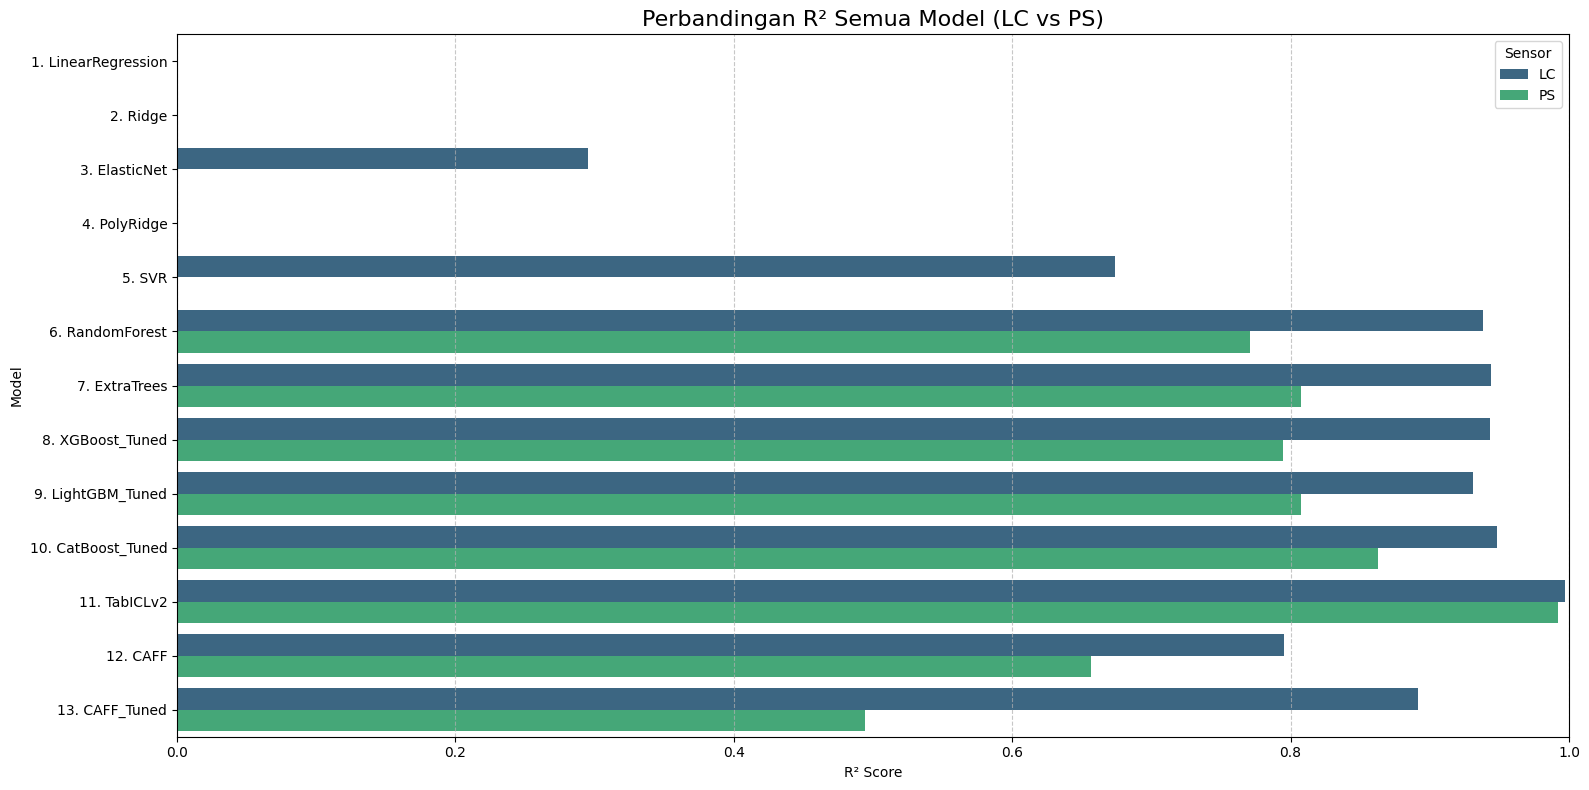

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan DataFrame Hasil
df_res_lc['Sensor'] = 'LC'
df_res_ps['Sensor'] = 'PS'
df_res_lc['Model'] = df_res_lc.index
df_res_ps['Model'] = df_res_ps.index

df_all = pd.concat([df_res_lc, df_res_ps])

plt.figure(figsize=(16, 8))
sns.barplot(data=df_all, x='R2', y='Model', hue='Sensor', palette='viridis')
plt.title('Perbandingan R² Semua Model (LC vs PS)', fontsize=16)
plt.xlabel('R² Score')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase6_barchart_r2.png', dpi=300)
plt.show()

Menghitung R² per fold untuk Top 5 Fast Models...


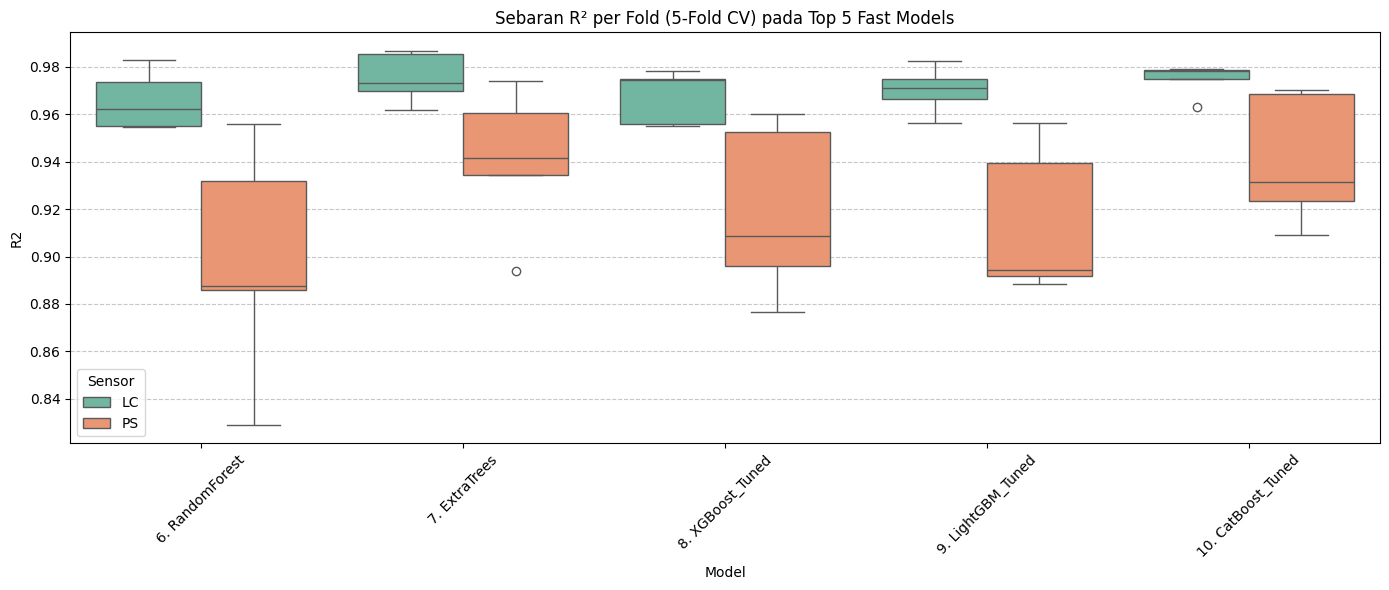

In [34]:
from sklearn.model_selection import cross_val_score

# Kita pilih 5 model tercepat dan terbaik untuk LC & PS agar tidak memakan waktu lama (seperti CAFF)
top_fast_models = ['6. RandomForest', '7. ExtraTrees', '8. XGBoost_Tuned', '9. LightGBM_Tuned', '10. CatBoost_Tuned']

cv_results = []
print("Menghitung R² per fold untuk Top 5 Fast Models...")
for m_name in top_fast_models:
    if m_name in best_models['LC']:
        model_lc = best_models['LC'][m_name]
        scores_lc = cross_val_score(model_lc, X_lc_scaled, y_lc, cv=list(skf.split(X_lc_scaled, labels_lc)) if 'lc' in m_name else list(skf.split(X_ps_scaled, labels_ps)), scoring='r2', n_jobs=-1)
        for s in scores_lc: cv_results.append({'Sensor': 'LC', 'Model': m_name, 'R2': s})
        
    if m_name in best_models['PS']:
        model_ps = best_models['PS'][m_name]
        scores_ps = cross_val_score(model_ps, X_ps_scaled, y_ps, cv=list(skf.split(X_lc_scaled, labels_lc)) if 'lc' in m_name else list(skf.split(X_ps_scaled, labels_ps)), scoring='r2', n_jobs=-1)
        for s in scores_ps: cv_results.append({'Sensor': 'PS', 'Model': m_name, 'R2': s})

df_cv = pd.DataFrame(cv_results)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_cv, x='Model', y='R2', hue='Sensor', palette='Set2')
plt.title('Sebaran R² per Fold (5-Fold CV) pada Top 5 Fast Models')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase6_boxplot_r2_fold.png', dpi=300)
plt.show()

Model Terbaik LC: 11. TabICLv2
Model Terbaik PS: 11. TabICLv2
Generating cross_val_predict untuk Parity Plot...


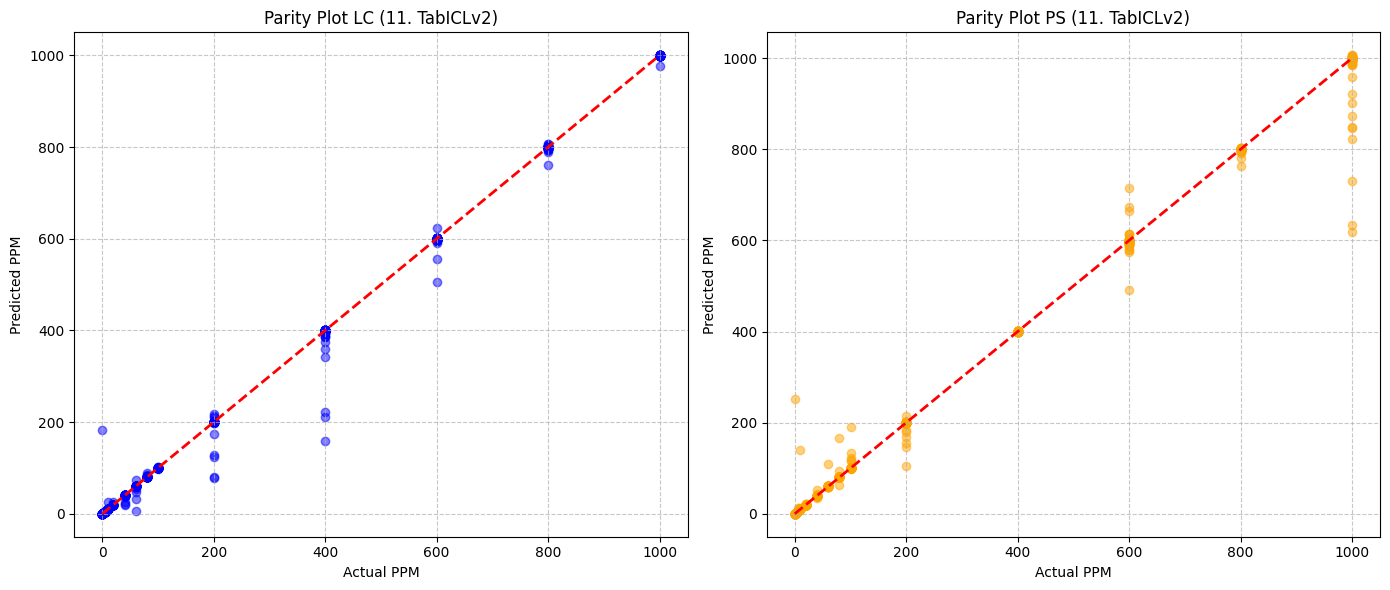

In [35]:
from sklearn.model_selection import cross_val_predict
import numpy as np

# Ambil nama model terbaik (R2 tertinggi)
best_model_name_lc = df_res_lc['R2'].astype(float).idxmax()
best_model_name_ps = df_res_ps['R2'].astype(float).idxmax()

print(f"Model Terbaik LC: {best_model_name_lc}")
print(f"Model Terbaik PS: {best_model_name_ps}")

model_lc_best = best_models['LC'][best_model_name_lc]
model_ps_best = best_models['PS'][best_model_name_ps]

print("Generating cross_val_predict untuk Parity Plot...")
# n_jobs=None untuk menghindari pickling error jika melibatkan PyTorch
jobs_lc = None if ('CAFF' in best_model_name_lc or 'Stacking' in best_model_name_lc or 'Voting' in best_model_name_lc) else -1
jobs_ps = None if ('CAFF' in best_model_name_ps or 'Stacking' in best_model_name_ps or 'Voting' in best_model_name_ps) else -1

y_pred_log_lc = cross_val_predict(model_lc_best, X_lc_scaled, y_lc, cv=list(skf.split(X_lc_scaled, labels_lc)), n_jobs=jobs_lc)
y_pred_log_ps = cross_val_predict(model_ps_best, X_ps_scaled, y_ps, cv=list(skf.split(X_ps_scaled, labels_ps)), n_jobs=jobs_ps)

# Inverse transform
y_true_inv_lc = (10 ** y_lc) - 1
y_pred_inv_lc = np.maximum(0, (10 ** y_pred_log_lc) - 1)

y_true_inv_ps = (10 ** y_ps) - 1
y_pred_inv_ps = np.maximum(0, (10 ** y_pred_log_ps) - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Parity Plot LC
axes[0].scatter(y_true_inv_lc, y_pred_inv_lc, alpha=0.5, color='blue')
axes[0].plot([0, 1000], [0, 1000], 'r--', lw=2)
axes[0].set_title(f'Parity Plot LC ({best_model_name_lc})')
axes[0].set_xlabel('Actual PPM')
axes[0].set_ylabel('Predicted PPM')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Parity Plot PS
axes[1].scatter(y_true_inv_ps, y_pred_inv_ps, alpha=0.5, color='orange')
axes[1].plot([0, 1000], [0, 1000], 'r--', lw=2)
axes[1].set_title(f'Parity Plot PS ({best_model_name_ps})')
axes[1].set_xlabel('Actual PPM')
axes[1].set_ylabel('Predicted PPM')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase6_parity_plot.png', dpi=300)
plt.show()

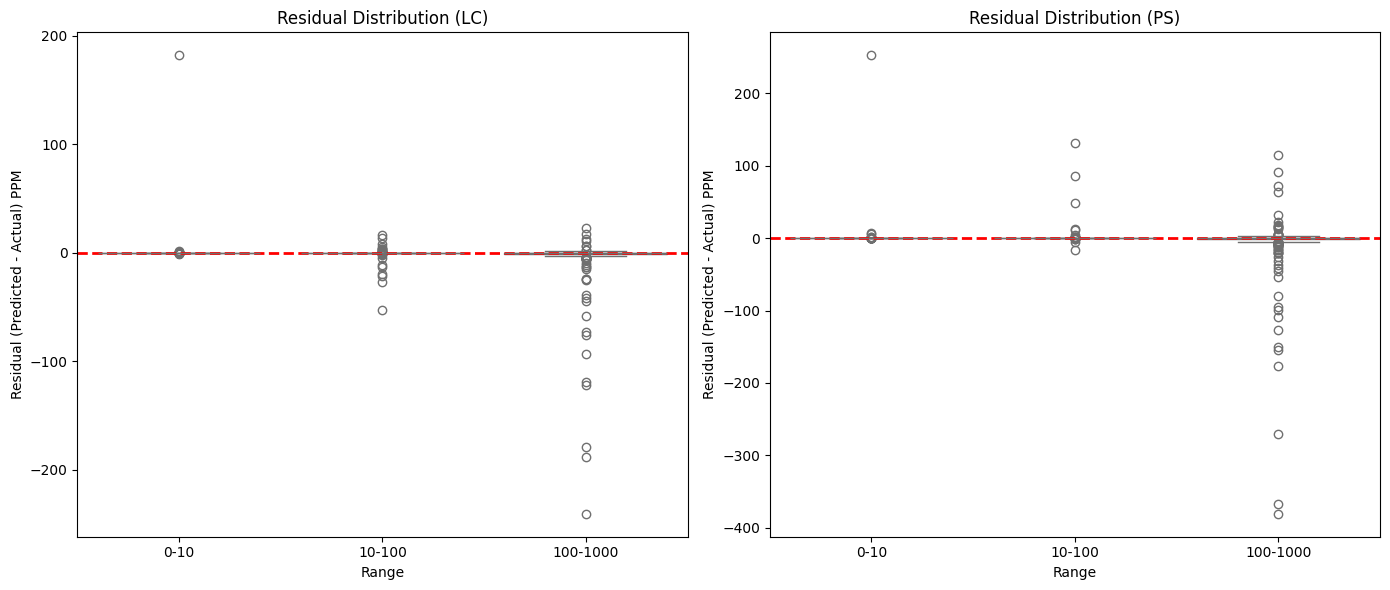

In [36]:
def plot_residuals(y_true, y_pred, sensor_name, ax):
    res = y_pred - y_true
    
    # Kategori range ppm
    ranges = []
    for val in y_true:
        if val <= 10: ranges.append('0-10')
        elif val <= 100: ranges.append('10-100')
        else: ranges.append('100-1000')
        
    df_res = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred, 'Residual': res, 'Range': ranges})
    
    sns.boxplot(data=df_res, x='Range', y='Residual', ax=ax, order=['0-10', '10-100', '100-1000'], palette='pastel')
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'Residual Distribution ({sensor_name})')
    ax.set_ylabel('Residual (Predicted - Actual) PPM')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_residuals(y_true_inv_lc, y_pred_inv_lc, 'LC', axes[0])
plot_residuals(y_true_inv_ps, y_pred_inv_ps, 'PS', axes[1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase6_residual_plot.png', dpi=300)
plt.show()

Membuat Feature Importance menggunakan SHAP pada XGBoost_Tuned...


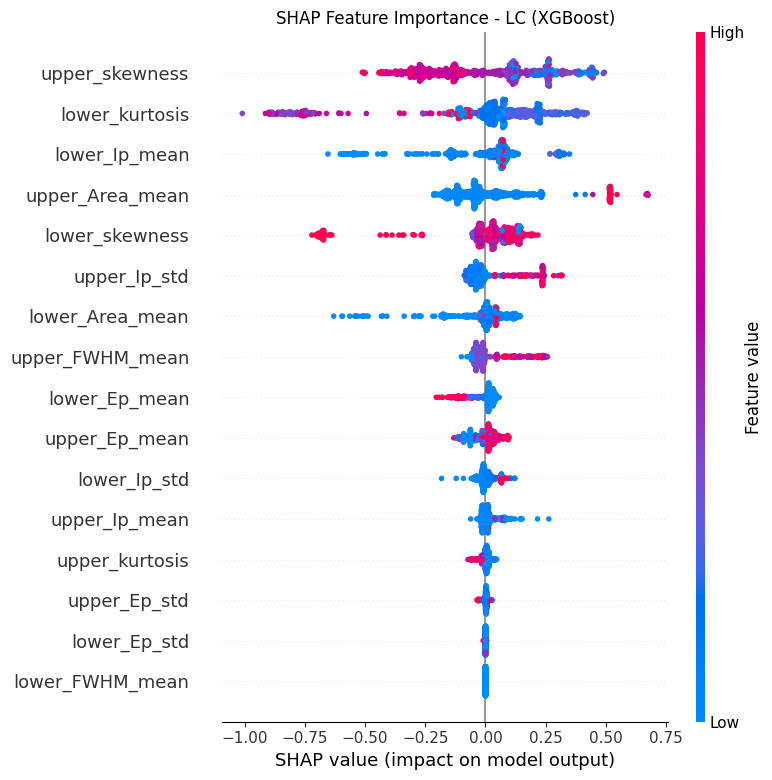

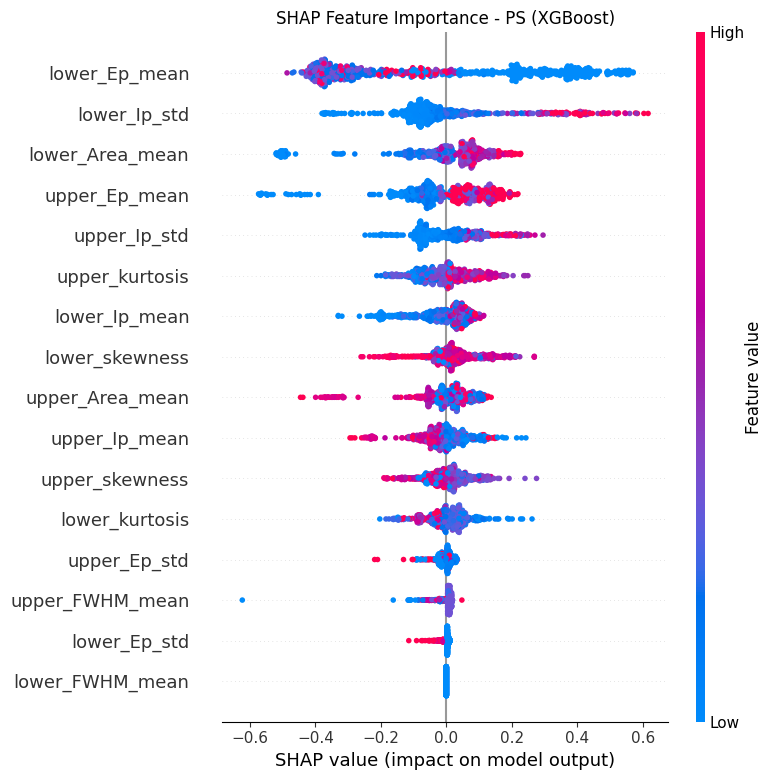

In [37]:
import shap

print("Membuat Feature Importance menggunakan SHAP pada XGBoost_Tuned...")

if '8. XGBoost_Tuned' in best_models['LC']:
    model_shap_lc = best_models['LC']['8. XGBoost_Tuned']
    model_shap_lc.fit(X_lc_scaled, y_lc) # Fit ulang di seluruh data untuk interpretasi
    explainer_lc = shap.TreeExplainer(model_shap_lc)
    shap_values_lc = explainer_lc.shap_values(X_lc_scaled)
    
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Feature Importance - LC (XGBoost)")
    shap.summary_plot(shap_values_lc, X_lc_scaled, feature_names=feature_cols, show=False)
    plt.savefig(OUTPUT_DIR / 'phase6_shap_lc.png', dpi=300, bbox_inches='tight')
    plt.show()

if '8. XGBoost_Tuned' in best_models['PS']:
    model_shap_ps = best_models['PS']['8. XGBoost_Tuned']
    model_shap_ps.fit(X_ps_scaled, y_ps)
    explainer_ps = shap.TreeExplainer(model_shap_ps)
    shap_values_ps = explainer_ps.shap_values(X_ps_scaled)
    
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Feature Importance - PS (XGBoost)")
    shap.summary_plot(shap_values_ps, X_ps_scaled, feature_names=feature_cols, show=False)
    plt.savefig(OUTPUT_DIR / 'phase6_shap_ps.png', dpi=300, bbox_inches='tight')
    plt.show()

### 🏆 Kesimpulan & Dashboard Ringkasan
- Visualisasi di atas menunjukkan perbandingan performa model LC vs PS.
- Parity plot dan Residual plot membuktikan seberapa baik model terbaik (otomatis dipilih berdasarkan R²) memprediksi pada berbagai rentang konsentrasi.
- Interpretasi SHAP menunjukkan fitur-fitur (dari total 16 fitur Dual-Peak) yang paling berpengaruh dalam prediksi ppm.
- Seluruh grafik telah tersimpan secara otomatis sebagai PNG resolusi tinggi di dalam folder `output/`.